# Exploratory Data Analysis (EDA)

In [ ]:
import sys
from pathlib import Path
import pickle
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import category_encoders as ce

# Make src/ importable from the notebook
project_root = Path.cwd().resolve()
if (project_root / "src").exists():
    src_path = project_root / "src"
elif (project_root.parent / "src").exists():
    project_root = project_root.parent
    src_path = project_root / "src"
else:
    raise FileNotFoundError(f"Could not find src/ from cwd={Path.cwd().resolve()}")

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Setup
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

2026-04-18 21:22:39 - __main__ - INFO - Project root: D:\Projects\TakeHomeProject
2026-04-18 21:22:39 - __main__ - INFO - Project root: D:\Projects\TakeHomeProject
2026-04-18 21:22:39 - __main__ - INFO - Project root: D:\Projects\TakeHomeProject
2026-04-18 21:22:39 - __main__ - INFO - Project root: D:\Projects\TakeHomeProject


# Paths

In [254]:
cwd = Path.cwd().resolve()
if (cwd / "data" / "raw").exists():
    root_dir = cwd
elif (cwd.parent / "data" / "raw").exists():
    root_dir = cwd.parent
else:
    raise FileNotFoundError(f"Could not find data/raw from cwd={cwd}")

cols_path = root_dir / "data" / "raw" / "census-bureau.columns"
data_path = root_dir / "data" / "raw" / "census-bureau.data"

print("CWD:", cwd)
print("Root:", root_dir)
print("Columns file exists:", cols_path.exists())
print("Data file exists:", data_path.exists())


cwd = Path.cwd().resolve()
if (cwd / "data" / "processed").exists():
    processed_dir = cwd / "data" / "processed"
elif (cwd.parent / "data" / "processed").exists():
    processed_dir = cwd.parent / "data" / "processed"
else:
    processed_dir = cwd / "data" / "processed"
    processed_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving to: {processed_dir}")

CWD: D:\Projects\TakeHomeProject\notebooks
Root: D:\Projects\TakeHomeProject
Columns file exists: True
Data file exists: True
Saving to: D:\Projects\TakeHomeProject\data\processed


# Data Engineering

## Step 1: Load Raw Data

In [13]:
columns = [line.strip() for line in cols_path.read_text(encoding="utf-8").splitlines() if line.strip()]
columns

['age',
 'class of worker',
 'detailed industry recode',
 'detailed occupation recode',
 'education',
 'wage per hour',
 'enroll in edu inst last wk',
 'marital stat',
 'major industry code',
 'major occupation code',
 'race',
 'hispanic origin',
 'sex',
 'member of a labor union',
 'reason for unemployment',
 'full or part time employment stat',
 'capital gains',
 'capital losses',
 'dividends from stocks',
 'tax filer stat',
 'region of previous residence',
 'state of previous residence',
 'detailed household and family stat',
 'detailed household summary in household',
 'weight',
 'migration code-change in msa',
 'migration code-change in reg',
 'migration code-move within reg',
 'live in this house 1 year ago',
 'migration prev res in sunbelt',
 'num persons worked for employer',
 'family members under 18',
 'country of birth father',
 'country of birth mother',
 'country of birth self',
 'citizenship',
 'own business or self employed',
 "fill inc questionnaire for veteran's admin"

In [14]:
df = pd.read_csv(
    data_path,
    header=None,
    names=columns,
    na_values=["?"],
    skipinitialspace=True
)

In [15]:
df

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,Not in universe,0,0,7th and 8th grade,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,Canada,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
199519,65,Self-employed-incorporated,37,2,11th grade,0,Not in universe,Married-civilian spouse present,Business and repair services,Executive admin and managerial,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
199520,47,Not in universe,0,0,Some college but no degree,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,Poland,Poland,Germany,Foreign born- U S citizen by naturalization,0,Not in universe,2,52,95,- 50000.
199521,16,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.


In [16]:
df.shape

(199523, 42)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         199523 non-null  int64  
 1   class of worker                             199523 non-null  object 
 2   detailed industry recode                    199523 non-null  int64  
 3   detailed occupation recode                  199523 non-null  int64  
 4   education                                   199523 non-null  object 
 5   wage per hour                               199523 non-null  int64  
 6   enroll in edu inst last wk                  199523 non-null  object 
 7   marital stat                                199523 non-null  object 
 8   major industry code                         199523 non-null  object 
 9   major occupation code                       199523 non-null  object 
 

**Observation**:
1. Dataset size is 199,523 rows and 42 columns, which is strong enough for reliable modeling and segmentation.
2. Feature mix is highly categorical: 29 object columns vs 13 numeric columns. This means encoding strategy will strongly affect classifier quality.
3. Missingness is low but present: hispanic origin has missing values while most other columns are complete.
4. Memory footprint is manageable at around 64 MB, so full in-memory EDA and model training is practical on a laptop.
5. Weight is float type (expected for survey weights), so we should report both unweighted and weighted class summaries.

In [18]:
df.describe()

,age,detailed industry recode,detailed occupation recode,wage per hour,capital gains,capital losses,dividends from stocks,weight,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,year
count,199523.000000,199523.000000,199523.000000,199523.000000,199523.00000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000
mean,34.494199,15.352320,11.306556,55.426908,434.71899,37.313788,197.529533,1740.380269,1.956180,0.175438,1.514833,23.174897,94.499672
std,22.310895,18.067129,14.454204,274.896454,4697.53128,271.896428,1984.163658,993.768156,2.365126,0.553694,0.851473,24.411488,0.500001
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,37.870000,0.000000,0.000000,0.000000,0.000000,94.000000
25%,15.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1061.615000,0.000000,0.000000,2.000000,0.000000,94.000000
50%,33.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1618.310000,1.000000,0.000000,2.000000,8.000000,94.000000
75%,50.000000,33.000000,26.000000,0.000000,0.00000,0.000000,0.000000,2188.610000,4.000000,0.000000,2.000000,52.000000,95.000000
max,90.000000,51.000000,46.000000,9999.000000,99999.00000,4608.000000,99999.000000,18656.300000,6.000000,2.000000,2.000000,52.000000,95.000000


**Observation:**

1. We have `199,523` people, so this is a large enough sample to trust overall patterns and not overreact to noise.
2. The average age is `34.5` with a full range from `0` (interesting) to `90`, so the dataset mixes children, working adults, and retirees in one population.
3. For wage per hour, `75%` of people are at `0`, so hourly wage is missing or not applicable for most records, not a normal salary-like field.
4. Capital gains are 0 for at least `75%` of people but can hit `99,999`, which means very few people have very large gains that can distort averages. (Unfortunate, but very realistic)
5. Capital losses show the same pattern (mostly `0`, rare large values), so typical people have no reported losses while a small group has notable financial activity.
6. Dividends from stocks are also mostly `0` with rare extreme values up to `99,999`, pointing to a small investment-heavy subgroup.
7. The mean is much larger than the median in multiple money columns, which confirms strong right-skew and outlier-driven behavior.
8. Weeks worked ranges from `0` to `52`, with median 8 and upper quartile `52`, meaning one big group barely worked and another worked nearly full-year.
9. Number of employers is usually low (median `1`, max `6`), so most people show limited employer switching in the year.
10. Year is only `94` or `95`, so this is a two-year snapshot rather than a long historical panel.
11. Weight ranges roughly from `38` to `18,656`, meaning each row represents very different population sizes and weighted reporting is essential.


**What does this tell us?**

The `1994–95` US population was economically polarized. Most people earned little with sporadic part-time work (median `8` weeks), while a small elite had substantial investment income; the wildly varying survey weights indicate deliberate stratified sampling to capture this stark inequality across demographic groups.

## Step 2: Data Visualization

### Target Label Distribution

In [20]:
df["label"].value_counts()

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

C:\Users\Shreejit\AppData\Local\Temp\ipykernel_5792\371837067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", order=order, palette="Set2")


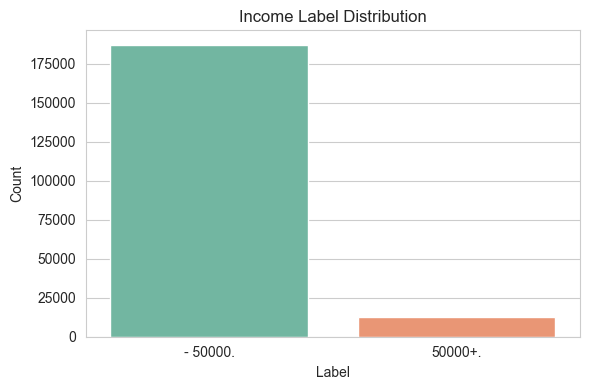

In [19]:
plt.figure(figsize=(6, 4))
order = df["label"].astype(str).str.strip().value_counts().index
sns.countplot(data=df, x="label", order=order, palette="Set2")
plt.title("Income Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

A HUUUUGE data imbalance - Completely biased

What this tells me is:
1. Classification Model even if it always predicts -50000 everytime it will be right 90% of the time. However, for JPMC its the rarer audience that accounts for the major billables.
2. Only accuracy will not help me during evaluation, it calls for the complete classification report (Precision, Recall, F-1, AUC)

**My intuition here**

Given the strong target imbalance, it calls for engineering additional features to improve detection of the 50K+ segment, so the model can identify high-value prospects more reliably rather than just optimizing overall accuracy.

---

### Age v/s Income

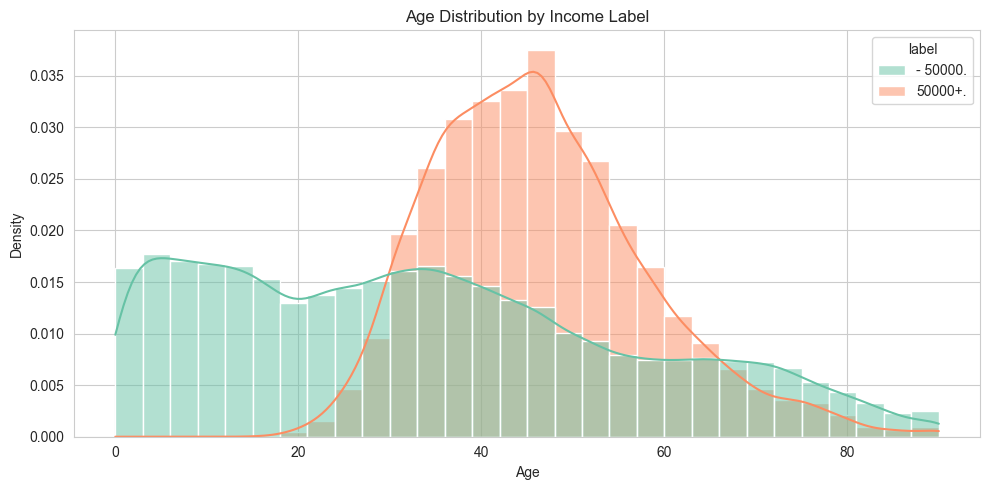

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="age",
    hue="label",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False,
    palette="Set2"
)
plt.title("Age Distribution by Income Label")
plt.xlabel("Age")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

**Observation:**
1. The 50000+ group is concentrated in mid-life, peaking roughly around ages 40–50.
2. The -50000. group is much broader, with strong presence at very young ages and also in older ages.
3. Age clearly has predictive signal for income band, but not enough alone because both classes overlap heavily between about 30 and 60.

**Intuition:**

While it is not a deciding factor, mostly if the age is between 20-60 years we need to consider for them to have 50k+ income over people who are below 20 or over 60.

---

### Weeks Worked v/s Income

In [42]:
# plt.figure(figsize=(8, 5))
# # sns.boxplot(data=df, x="label", y="weeks worked in year")
# # sns.violinplot(data=df, x="label", y="weeks worked in year", inner="quartile")
# sns.stripplot(data=df.sample(5000, random_state=42), x="label", y="weeks worked in year", alpha=0.2, color="black")
# plt.title("Weeks Worked in Year by Income Label")
# plt.xlabel("Income Label")
# plt.ylabel("Weeks Worked")
# plt.tight_layout()
# plt.show()

Polishing the experimentation in the above code cell

C:\Users\Shreejit\AppData\Local\Temp\ipykernel_5792\902427799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Shreejit\AppData\Local\Temp\ipykernel_5792\902427799.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


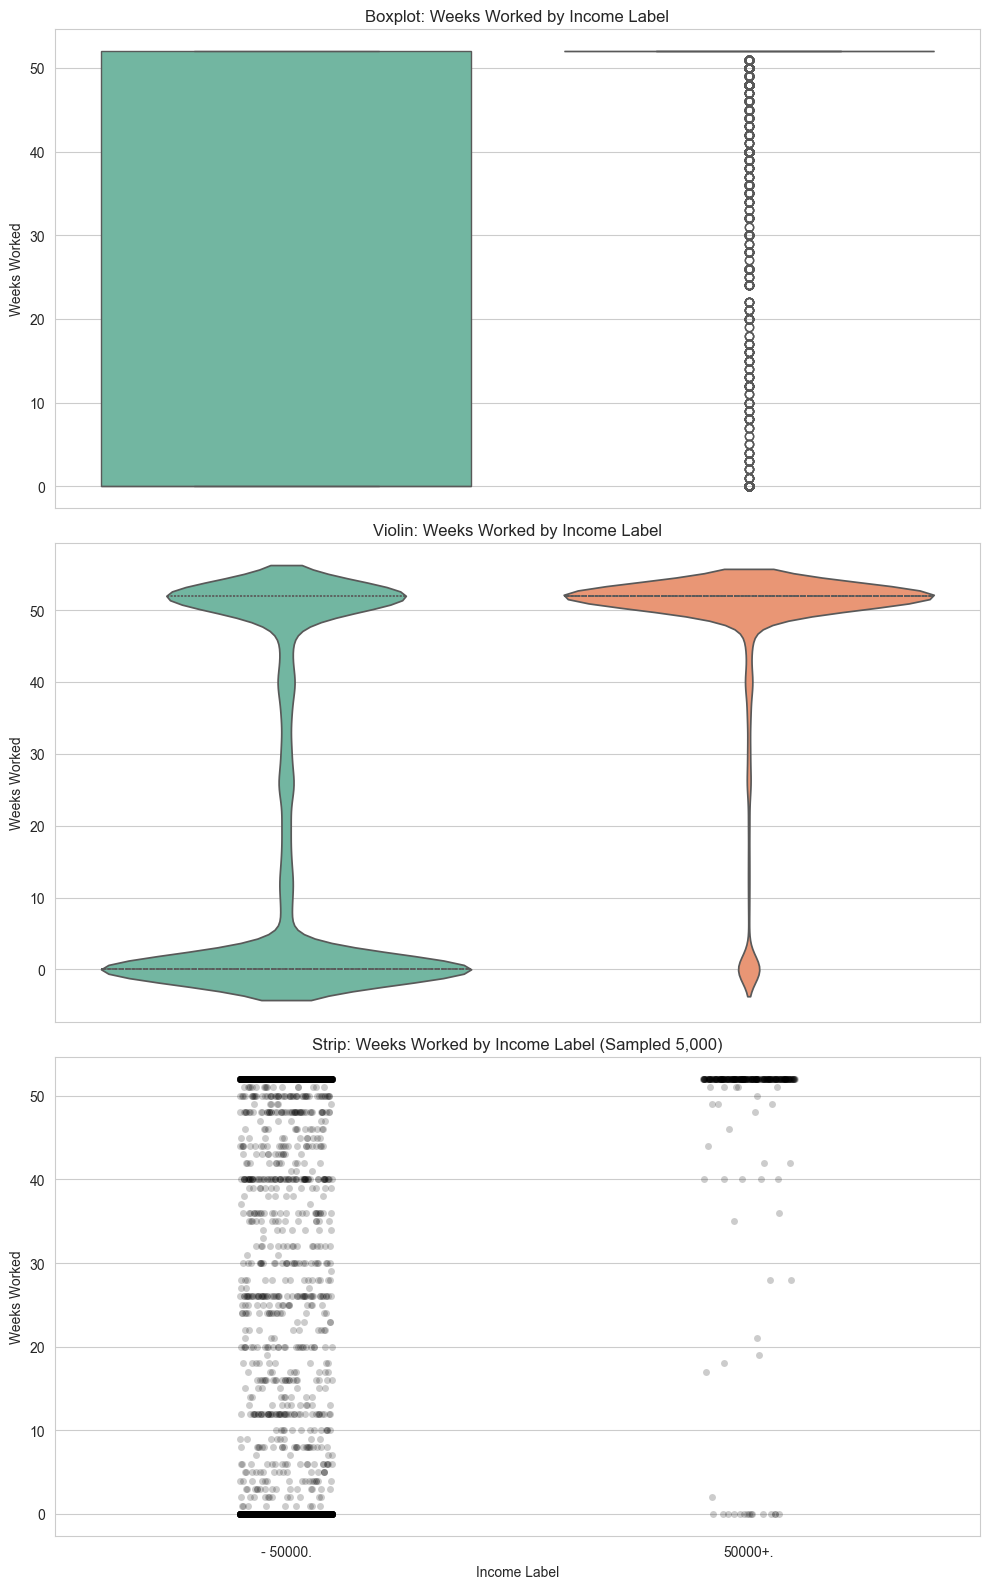

In [48]:
fig, axes = plt.subplots(3, 1, figsize=(10, 16), sharex=True)

# 1) Boxplot
sns.boxplot(
    data=df,
    x="label",
    y="weeks worked in year",
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Boxplot: Weeks Worked by Income Label")
axes[0].set_xlabel("")
axes[0].set_ylabel("Weeks Worked")

# 2) Violin plot
sns.violinplot(
    data=df,
    x="label",
    y="weeks worked in year",
    inner="quartile",
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Violin: Weeks Worked by Income Label")
axes[1].set_xlabel("")
axes[1].set_ylabel("Weeks Worked")

# 3) Strip plot
sns.stripplot(
    data=df.sample(5000, random_state=42),
    x="label",
    y="weeks worked in year",
    alpha=0.2,
    color="black",
    ax=axes[2]
)
axes[2].set_title("Strip: Weeks Worked by Income Label (Sampled 5,000)")
axes[2].set_xlabel("Income Label")
axes[2].set_ylabel("Weeks Worked")

plt.tight_layout()
plt.show()

**Intuition:**

Despite some outliers, the data is concentrated at the two extremes: most people either worked the full year or not at all. The low-income group is heavily represented among those with little to no work, while the 50K+ group is concentrated among full-year workers.

---

### Capital Gains

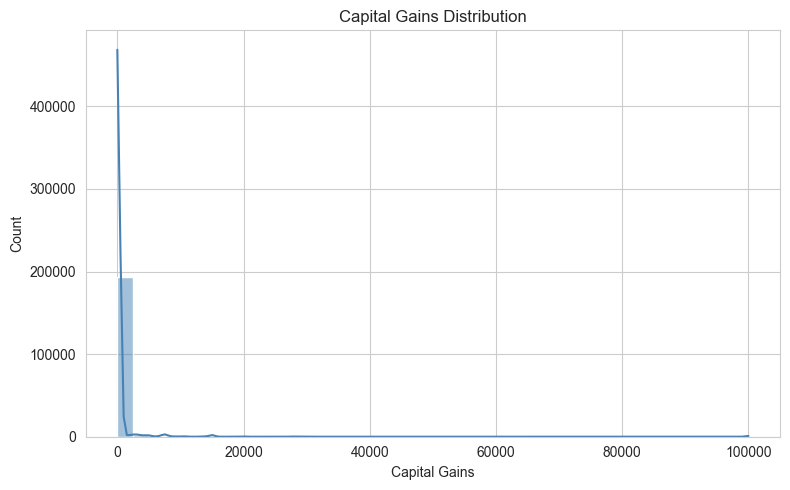

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(df["capital gains"], bins=40, kde=True, color="steelblue")
plt.title("Capital Gains Distribution")
plt.xlabel("Capital Gains")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

C:\Users\Shreejit\AppData\Local\Temp\ipykernel_5792\668441891.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, palette=label_palette)


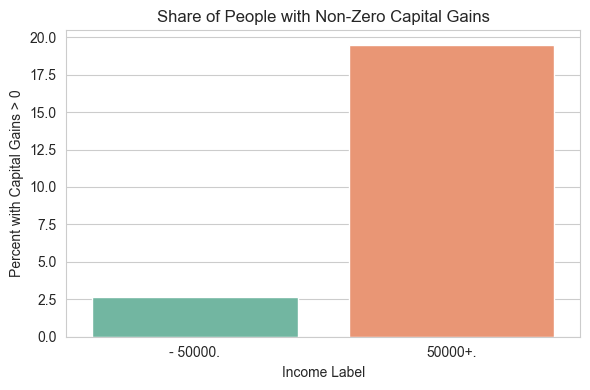

In [51]:
tmp = df.copy()
tmp["label"] = tmp["label"].astype(str).str.strip()
tmp["has_capital_gains"] = (tmp["capital gains"] > 0).astype(int)

pos_label = [x for x in tmp["label"].unique() if "50000+" in x][0]
neg_label = [x for x in tmp["label"].unique() if "50000+" not in x][0]

# Maintaining the order from before
label_order = [neg_label, pos_label]

rate = (
    tmp.groupby("label")["has_capital_gains"]
    .mean()
    .mul(100)
    .round(2)
    .reindex(label_order)
)

set2 = sns.color_palette("Set2", 2)
label_palette = {
    neg_label: set2[0],
    pos_label: set2[1]
}

plt.figure(figsize=(6, 4))
sns.barplot(x=rate.index, y=rate.values, palette=label_palette)
plt.title("Share of People with Non-Zero Capital Gains")
plt.xlabel("Income Label")
plt.ylabel("Percent with Capital Gains > 0")
plt.tight_layout()
plt.show()

AAAWWEESOMEEE!

The `has_capital_gains` column significantly helps us to find the Higher-Earning Segment.

In [52]:
tmp = df.copy()
tmp["label"] = tmp["label"].astype(str).str.strip()
tmp["has_capital_gains"] = (tmp["capital gains"] > 0).astype(int)

overlap_counts = pd.crosstab(
    tmp["label"],
    tmp["has_capital_gains"],
    margins=True
).rename(columns={0: "zero_capital_gains", 1: "nonzero_capital_gains"})

print("Overlap counts:")
display(overlap_counts)

overlap_pct_within_label = pd.crosstab(
    tmp["label"],
    tmp["has_capital_gains"],
    normalize="index"
).rename(columns={0: "zero_capital_gains_pct", 1: "nonzero_capital_gains_pct"}) * 100

print("Within-income percentages:")
display(overlap_pct_within_label.round(2))

nonzero_split = (
    tmp[tmp["has_capital_gains"] == 1]["label"]
    .value_counts()
    .to_frame("nonzero_capital_gains_count")
)
nonzero_split["share_of_all_nonzero_gains_pct"] = (
    nonzero_split["nonzero_capital_gains_count"] / nonzero_split["nonzero_capital_gains_count"].sum() * 100
).round(2)

print("Split among people with non-zero gains:")
display(nonzero_split)

Overlap counts:


has_capital_gains,zero_capital_gains,nonzero_capital_gains,All
label,,,
- 50000.,182174,4967,187141
50000+.,9970,2412,12382
All,192144,7379,199523


Within-income percentages:


has_capital_gains,zero_capital_gains_pct,nonzero_capital_gains_pct
label,,
- 50000.,97.35,2.65
50000+.,80.52,19.48


Split among people with non-zero gains:


,nonzero_capital_gains_count,share_of_all_nonzero_gains_pct
label,,
- 50000.,4967,67.31
50000+.,2412,32.69


**Observation**

The bar graph "Share of People with Non-Zero Capital Gains" we saw is of the 2nd table 3rd column.

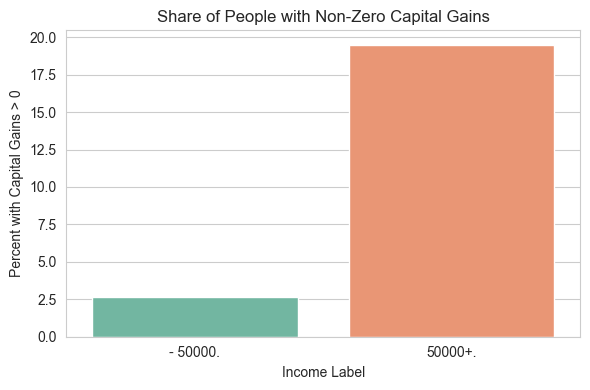

`has_capital_gains`>0 raises likelihood of 50K+ a lot but doesn't directly decide. It is not sufficient alone to identify most 50K+ people.



---

### Non-zero Capital Gains on a continuous projection to find Skewness

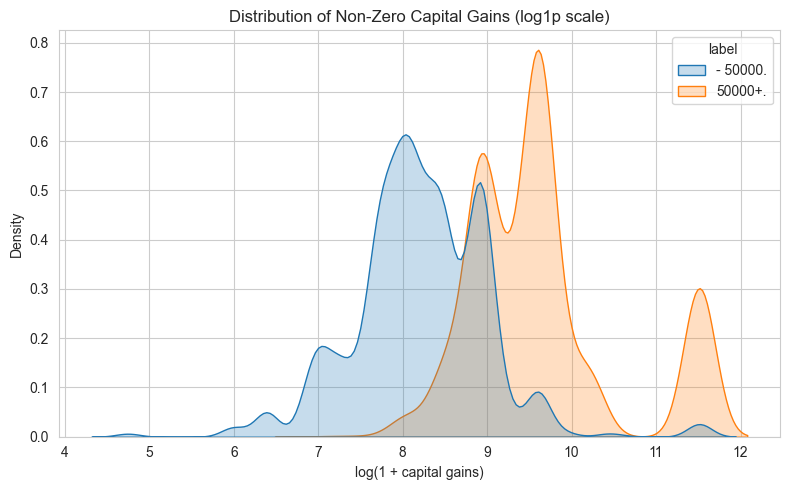

In [ ]:
nz = tmp[tmp["capital gains"] > 0].copy()
nz["log_capital_gains"] = np.log1p(nz["capital gains"])

plt.figure(figsize=(8, 5))
sns.kdeplot(data=nz, x="log_capital_gains", hue="label", common_norm=False, fill=True, alpha=0.25)
plt.title("Distribution of Non-Zero Capital Gains (log1p scale)")
plt.xlabel("log(1 + capital gains)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

**Observation:**

1. Among people who already have non-zero capital gains, the higher-income group is shifted to the right, meaning they tend to have larger gain amounts.
2. So capital gains magnitude carries real signal for income classification, not just whether gains are present.

---

### Education v/s Income

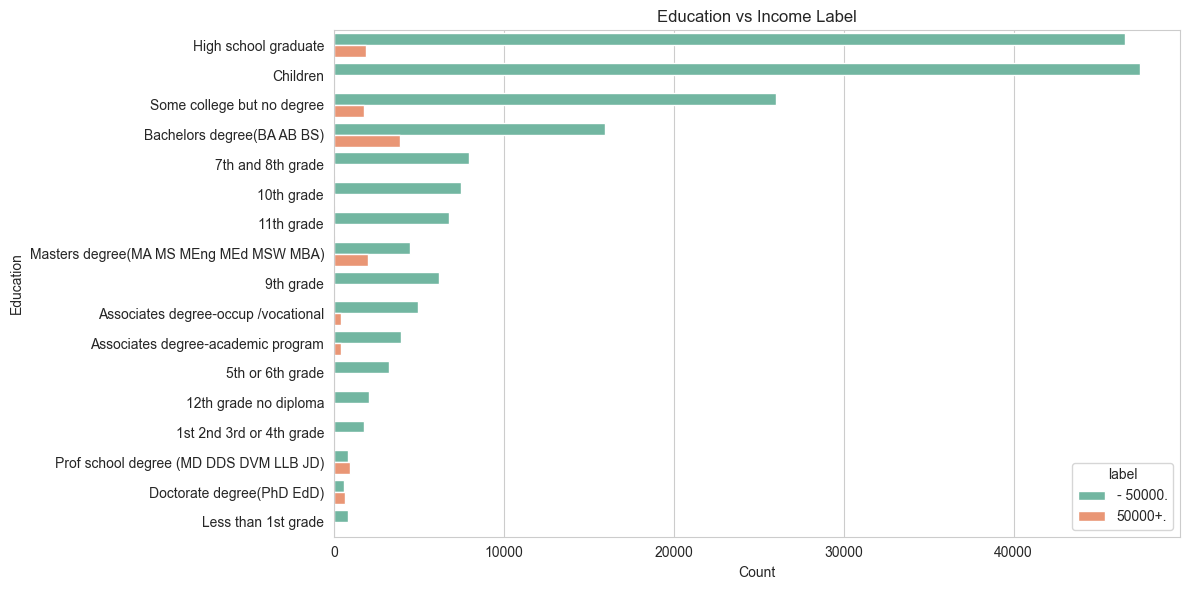

In [35]:
plt.figure(figsize=(12, 6))
edu_order = df["education"].value_counts().index
sns.countplot(data=df, y="education", hue="label", order=edu_order, palette="Set2")
plt.title("Education vs Income Label")
plt.xlabel("Count")
plt.ylabel("Education")
plt.tight_layout()
plt.show()

**Observation:**

Bachelor's degree appears to be a major income threshold; below that, almost everyone is lower-income.

### Important Misc Plots 
Which help us during data cleaning

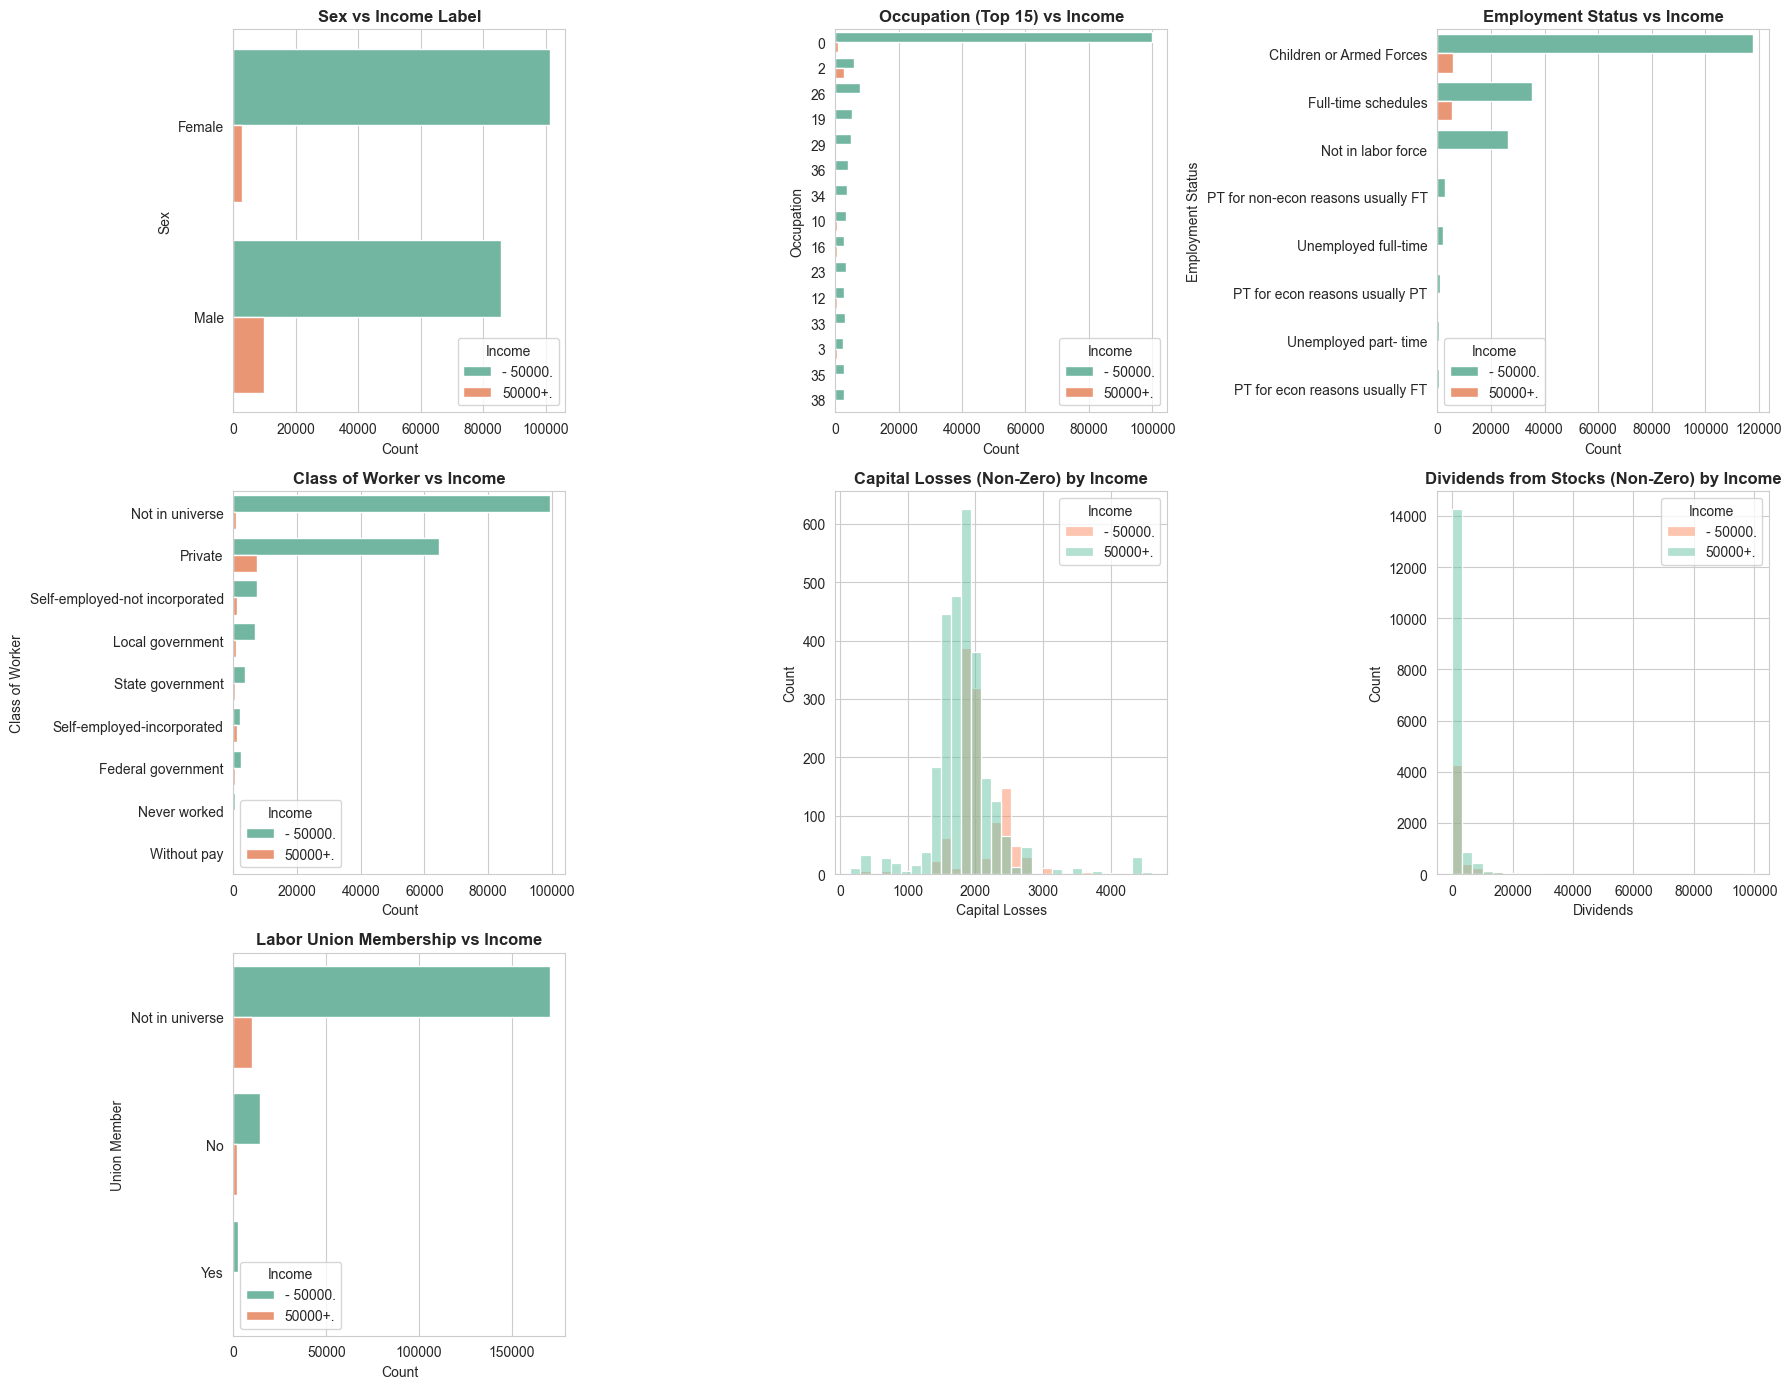

In [55]:
tmp_analysis = df.copy()
tmp_analysis["label"] = tmp_analysis["label"].astype(str).str.strip()

pos_label_val = [x for x in tmp_analysis["label"].unique() if "50000+" in x][0]
neg_label_val = [x for x in tmp_analysis["label"].unique() if "50000+" not in x][0]
label_order_analysis = [neg_label_val, pos_label_val]

set2_palette = sns.color_palette("Set2", 2)
color_dict = {neg_label_val: set2_palette[0], pos_label_val: set2_palette[1]}

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

sex_order = tmp_analysis["sex"].value_counts().index
sns.countplot(data=tmp_analysis, y="sex", hue="label", order=sex_order, palette=color_dict, ax=axes[0])
axes[0].set_title("Sex vs Income Label", fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Sex")
axes[0].legend(title="Income", labels=label_order_analysis)

occ_order = tmp_analysis["detailed occupation recode"].value_counts().head(15).index
occ_data = tmp_analysis[tmp_analysis["detailed occupation recode"].isin(occ_order)]
sns.countplot(data=occ_data, y="detailed occupation recode", hue="label", order=occ_order, palette=color_dict, ax=axes[1])
axes[1].set_title("Occupation (Top 15) vs Income", fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Occupation")
axes[1].legend(title="Income", labels=label_order_analysis)

empl_order = tmp_analysis["full or part time employment stat"].value_counts().index
sns.countplot(data=tmp_analysis, y="full or part time employment stat", hue="label", order=empl_order, palette=color_dict, ax=axes[2])
axes[2].set_title("Employment Status vs Income", fontweight="bold")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("Employment Status")
axes[2].legend(title="Income", labels=label_order_analysis)

worker_order = tmp_analysis["class of worker"].value_counts().index
sns.countplot(data=tmp_analysis, y="class of worker", hue="label", order=worker_order, palette=color_dict, ax=axes[3])
axes[3].set_title("Class of Worker vs Income", fontweight="bold")
axes[3].set_xlabel("Count")
axes[3].set_ylabel("Class of Worker")
axes[3].legend(title="Income", labels=label_order_analysis)

sns.histplot(data=tmp_analysis[tmp_analysis["capital losses"] > 0], x="capital losses", hue="label", bins=30, palette=color_dict, ax=axes[4])
axes[4].set_title("Capital Losses (Non-Zero) by Income", fontweight="bold")
axes[4].set_xlabel("Capital Losses")
axes[4].set_ylabel("Count")
axes[4].legend(title="Income", labels=label_order_analysis)

sns.histplot(data=tmp_analysis[tmp_analysis["dividends from stocks"] > 0], x="dividends from stocks", hue="label", bins=30, palette=color_dict, ax=axes[5])
axes[5].set_title("Dividends from Stocks (Non-Zero) by Income", fontweight="bold")
axes[5].set_xlabel("Dividends")
axes[5].set_ylabel("Count")
axes[5].legend(title="Income", labels=label_order_analysis)

union_order = tmp_analysis["member of a labor union"].value_counts().index
sns.countplot(data=tmp_analysis, y="member of a labor union", hue="label", order=union_order, palette=color_dict, ax=axes[6])
axes[6].set_title("Labor Union Membership vs Income", fontweight="bold")
axes[6].set_xlabel("Count")
axes[6].set_ylabel("Union Member")
axes[6].legend(title="Income", labels=label_order_analysis)

axes[7].axis('off')
axes[8].axis('off')

plt.tight_layout()
plt.show()

#### Observation and Usability

- Sex vs Income: Clear imbalance with males having higher proportion of >50K income, making gender a moderately predictive feature for classification.

- Occupation vs Income: Certain occupations show strong skew toward high income, indicating this feature will be highly informative for segmentation and non-linear decision boundaries.

- Employment Status vs Income: Full-time employment strongly correlates with higher income, making this a high-signal feature for separating classes.

- Class of Worker vs Income: Private sector dominates both classes but government and self-employed categories show different income distributions, useful for segment-based modeling.

- Capital Losses (Non-Zero): Higher capital losses appear more frequently in >50K group, suggesting this numeric feature can help improve model discrimination.

- Dividends from Stocks (Non-Zero): Strong positive association with >50K income, making it a high-impact financial feature for classification.

- Labor Union Membership vs Income: Weak signal overall due to heavy skew toward non-union and missing categories, likely low importance but may add marginal value in combination with other features.

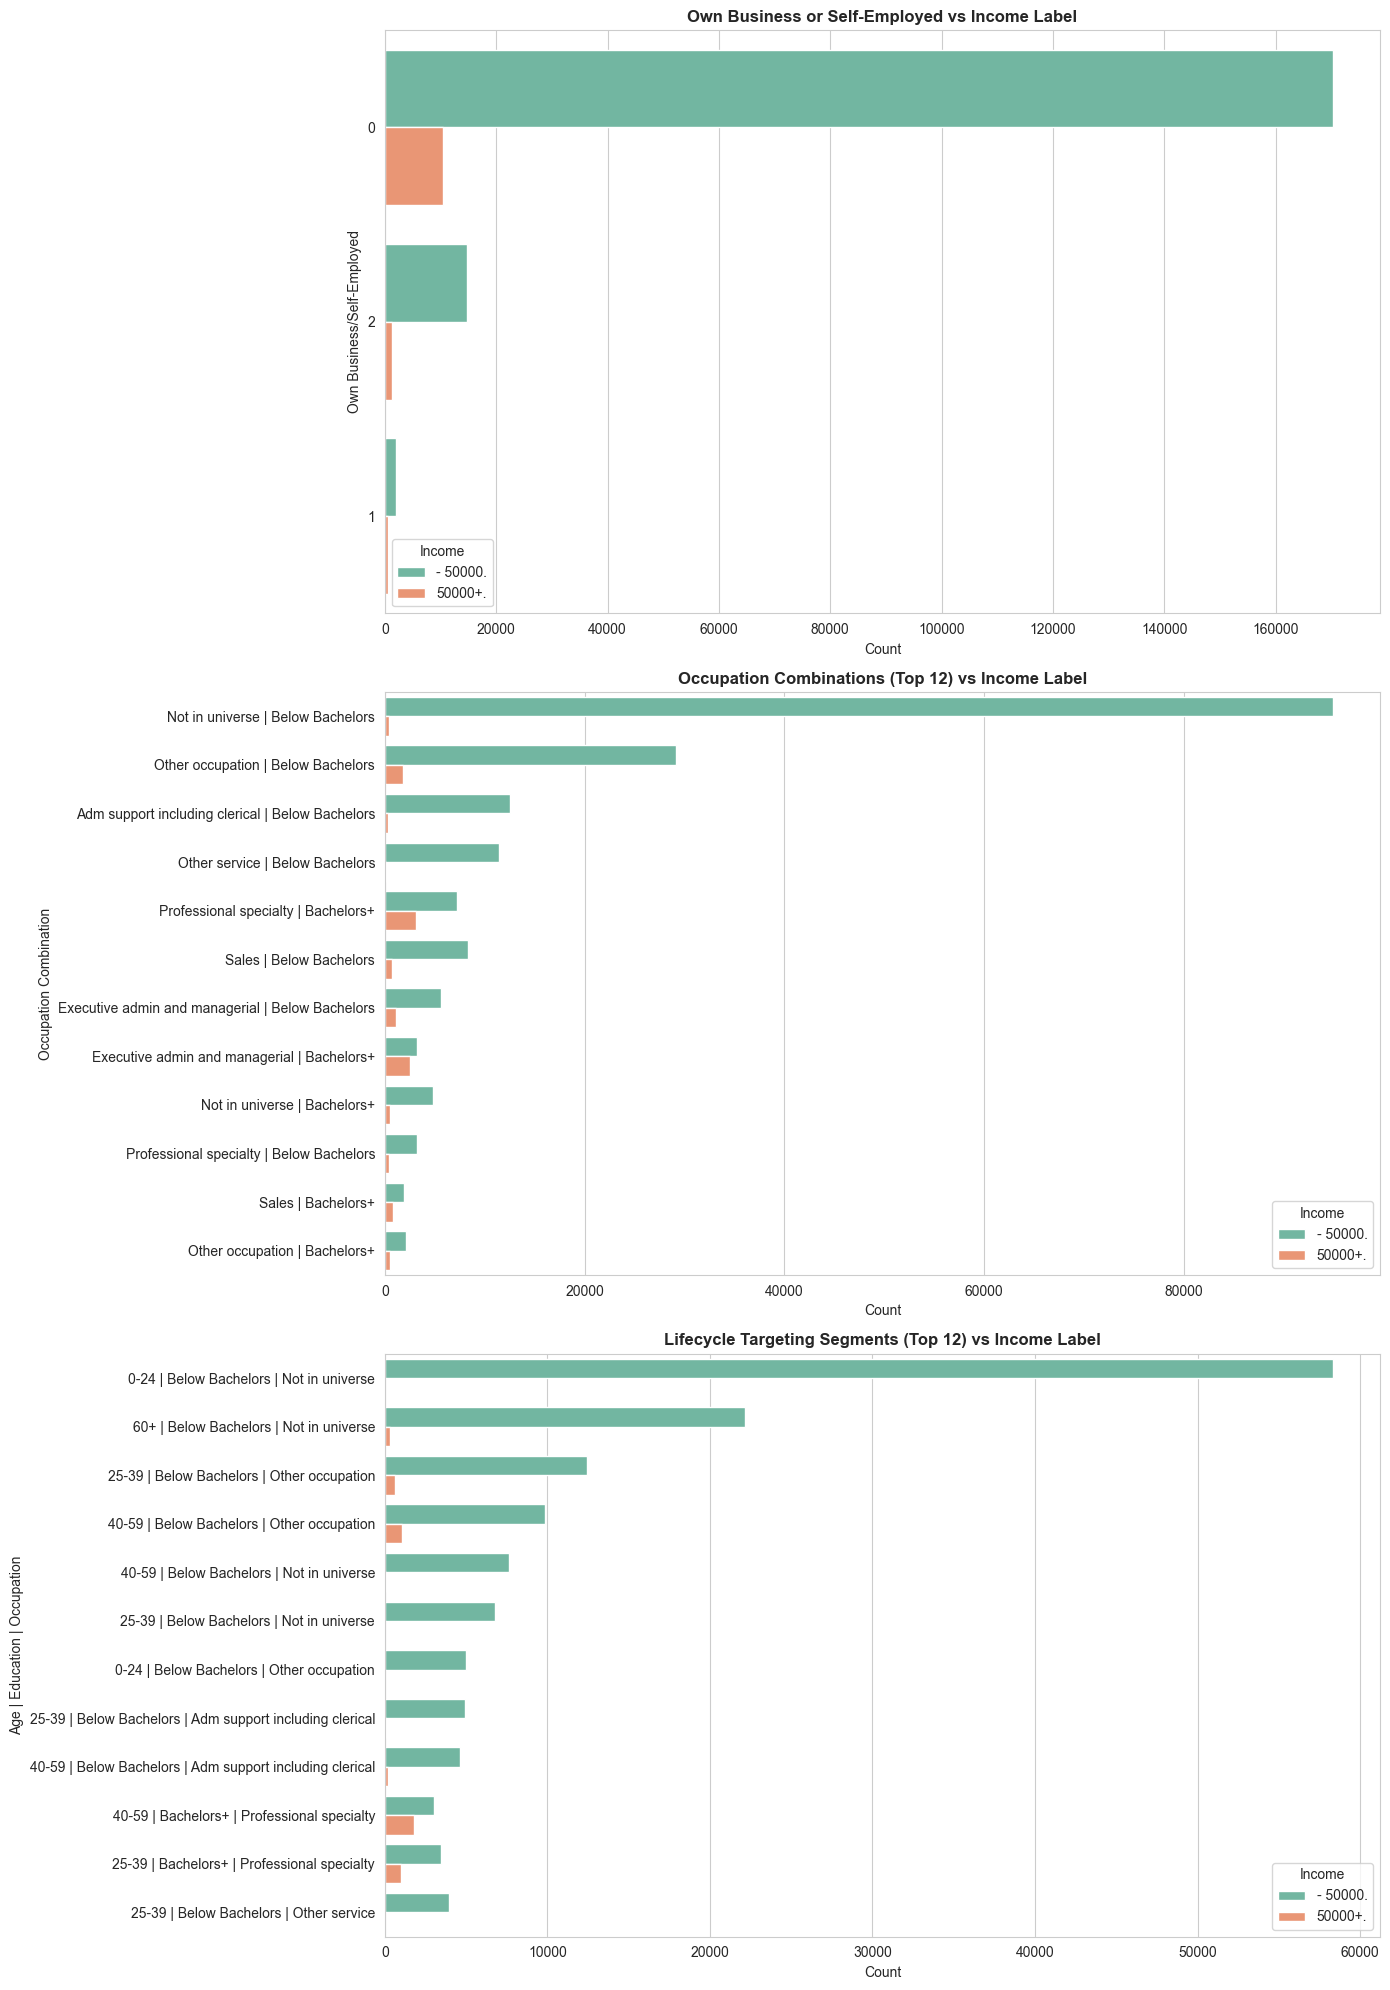

In [ ]:
seg = df.copy()
seg["label"] = seg["label"].astype(str).str.strip()

pos_lbl = [x for x in seg["label"].unique() if "50000+" in x][0]
neg_lbl = [x for x in seg["label"].unique() if "50000+" not in x][0]
seg_label_order = [neg_lbl, pos_lbl]
seg_palette = {neg_lbl: sns.color_palette("Set2", 2)[0], pos_lbl: sns.color_palette("Set2", 2)[1]}

edu_high = {
    "Bachelors degree(BA AB BS)",
    "Masters degree(MA MS MEng MEd MSW MBA)",
    "Prof school degree (MD DDS DVM LLB JD)",
    "Doctorate degree(PhD EdD)"
}
seg["edu_tier"] = np.where(seg["education"].isin(edu_high), "Bachelors+", "Below Bachelors")

top_occ = seg["major occupation code"].value_counts().head(6).index
seg["occ_group"] = np.where(seg["major occupation code"].isin(top_occ), seg["major occupation code"], "Other occupation")

fig, axes = plt.subplots(3, 1, figsize=(14, 20))

own_order = seg["own business or self employed"].value_counts().index
sns.countplot(
    data=seg,
    y="own business or self employed",
    hue="label",
    order=own_order,
    hue_order=seg_label_order,
    palette=seg_palette,
    ax=axes[0]
)
axes[0].set_title("Own Business or Self-Employed vs Income Label", fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Own Business/Self-Employed")

seg["occupation_combo"] = seg["occ_group"] + " | " + seg["edu_tier"]
combo_order = seg["occupation_combo"].value_counts().head(12).index
combo_df = seg[seg["occupation_combo"].isin(combo_order)]

sns.countplot(
    data=combo_df,
    y="occupation_combo",
    hue="label",
    order=combo_order,
    hue_order=seg_label_order,
    palette=seg_palette,
    ax=axes[1]
)
axes[1].set_title("Occupation Combinations (Top 12) vs Income Label", fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Occupation Combination")

age_bins = [0, 25, 40, 60, 100]
age_labels = ["0-24", "25-39", "40-59", "60+"]
seg["age_band"] = pd.cut(seg["age"], bins=age_bins, labels=age_labels, right=False)
seg["lifecycle_segment"] = seg["age_band"].astype(str) + " | " + seg["edu_tier"] + " | " + seg["occ_group"]

life_order = seg["lifecycle_segment"].value_counts().head(12).index
life_df = seg[seg["lifecycle_segment"].isin(life_order)]

sns.countplot(
    data=life_df,
    y="lifecycle_segment",
    hue="label",
    order=life_order,
    hue_order=seg_label_order,
    palette=seg_palette,
    ax=axes[2]
)
axes[2].set_title("Lifecycle Targeting Segments (Top 12) vs Income Label", fontweight="bold")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("Age | Education | Occupation")

for ax in axes:
    ax.legend(title="Income")

plt.tight_layout()
plt.show()

1. Most people in this data fall into one big basic group (“not in universe” + lower education), so we should keep that as its own segment.
2. People in professional jobs with a bachelor’s or higher look like a strong high-income segment.
3. Managers/executives with higher education also form a valuable segment.
4. Self-employed people are fewer, but many are high value, so they deserve their own segment.
5. Ages 25–59 show the clearest differences between groups, so this age range matters most for segmentation.
6. Education clearly changes outcomes even within the same job type, so we should keep education in the segmentation model.
7. If we include too many “not in universe” records, they can drown out useful patterns, so we should test clustering with and without them.

---

## Step 3: Data Preprocessing - Classification

Going to attend each column and manipulate it as needed

In [288]:
data = df.copy()

In [289]:
data.shape

(199523, 42)

In [290]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         199523 non-null  int64  
 1   class of worker                             199523 non-null  object 
 2   detailed industry recode                    199523 non-null  int64  
 3   detailed occupation recode                  199523 non-null  int64  
 4   education                                   199523 non-null  object 
 5   wage per hour                               199523 non-null  int64  
 6   enroll in edu inst last wk                  199523 non-null  object 
 7   marital stat                                199523 non-null  object 
 8   major industry code                         199523 non-null  object 
 9   major occupation code                       199523 non-null  object 
 

In [291]:
data.columns

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'ow

**Column Description**

- age: Age of the individual.

- class of worker: Type of employment (private, government, self-employed, etc.).

- detailed industry recode: Fine-grained industry classification of the job.

- detailed occupation recode: Fine-grained occupation classification.

- education: Highest level of education attained.

- wage per hour: Hourly wage earned.

- enroll in edu inst last wk: Whether enrolled in an educational institution recently.

- marital stat: Marital status of the individual.

- major industry code: Broad category of industry.

- major occupation code: Broad category of occupation.

- race: Racial category of the individual.

- hispanic origin: Hispanic/Latino background indicator.

- sex: Gender of the individual.

- member of a labor union: Whether the person is part of a labor union.

- reason for unemployment: Reason for being unemployed (if applicable).

- full or part time employment stat: Employment status (full-time/part-time).

- capital gains: Income from investments or asset sales.

- capital losses: Losses from investments.

- dividends from stocks: Income earned from stock dividends.

- tax filer stat: Tax filing status.

- region of previous residence: Previous geographic region lived in.

- state of previous residence: Previous state lived in.

- detailed household and family stat: Detailed household composition.

- detailed household summary in household: Summary of household structure.

- weight: Sampling weight representing population count.

- migration code-change in msa: Migration status within metropolitan areas.

- migration code-change in reg: Migration status across regions.

- migration code-move within reg: Movement within the same region.

- live in this house 1 year ago: Whether the person lived in the same house last year.

- migration prev res in sunbelt: Whether previous residence was in Sunbelt region.

- num persons worked for employer: Number of people employed by the employer.

- family members under 18: Number of family members below 18.

- country of birth father: Father’s country of birth.

- country of birth mother: Mother’s country of birth.

- country of birth self: Individual’s country of birth.

- citizenship: Citizenship status.

- own business or self employed: Whether self-employed or business owner.

- fill inc questionnaire for veteran's admin: Whether income info was provided for veterans administration.

- veterans benefits: Whether receiving veteran benefits.

- weeks worked in year: Number of weeks worked in the year.

- year: Year of data record.

- label: Income class (≤50K or >50K).

In task description it was mentioned we have 40 columns but in the data we have 42. In the first look here, seems like `'weight'` and `'year'` have no determining factor for modelling. Hence, dropping them.

In [292]:
data.drop(['year'], axis=1, inplace=True)

In [293]:
data.drop(['weight'], axis=1, inplace=True)

In [294]:
len(data.columns)

40

Now we have 40 columns as mentioned.

### Feature Engineering

#### Fixing Target

In [ ]:
data.label.value_counts()

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

In [296]:
data['label'] = data['label'].map({
    '- 50000.': 0,
    '50000+.': 1
})

In [297]:
data.label

0         0
1         0
2         0
3         0
4         0
         ..
199518    0
199519    0
199520    0
199521    0
199522    0
Name: label, Length: 199523, dtype: int64

#### Missing Values

In [298]:
missing = data.isna().sum()
print(missing[missing > 0])

hispanic origin                     874
state of previous residence         708
migration code-change in msa      99696
migration code-change in reg      99696
migration code-move within reg    99696
migration prev res in sunbelt     99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
dtype: int64


In [ ]:
classification_drop = [
    'migration code-change in msa',    # 50% missing, weak signal
    'migration code-change in reg',    # 50% missing
    'migration code-move within reg',  # 50% missing
    'migration prev res in sunbelt',   # 50% missing
    'country of birth father',         # too sparse, weak income link
    'country of birth mother',         # too sparse
    'country of birth self',           # citizenship captures this better
    'state of previous residence',     # weak signal
    'region of previous residence',    # weak signal
    'fill inc questionnaire for veteran\'s admin',  # administrative
    'live in this house 1 year ago',   # weak signal
    'hispanic origin',                 # classification is for marketing where we are looking for behaviors and income
]


data.drop(columns=classification_drop, inplace=True)

**List of columns that would not help a classification model:**

- weight: Sampling weight, not a real feature about the person, should be excluded from model training.

- year: Temporal identifier with no direct behavioral signal, likely adds noise unless modeling trends over time.

- major industry code & major occupation code: Keep either detailed or major, not both, to avoid multicollinearity.

- region/state of previous residence & migration-related features: Weak direct link to income, likely low predictive power and may introduce noise.

- country of birth father/mother/self: High cardinality and weak causal relation to income, better to drop or heavily group.

- fill inc questionnaire for veteran's admin: Likely administrative artifact, not meaningful for income prediction.

- reason for unemployment: Sparse and only relevant for a small subset, limited overall contribution.

- detailed household and family stat & detailed household summary: Highly granular and redundant, risk of overfitting.

- race & hispanic origin: Sensitive attributes, should be excluded to avoid bias and ensure fair modeling.

- label: Target variable, must not be used as input feature.

In [300]:
data.columns

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'sex', 'member of a labor union',
       'reason for unemployment', 'full or part time employment stat',
       'capital gains', 'capital losses', 'dividends from stocks',
       'tax filer stat', 'detailed household and family stat',
       'detailed household summary in household',
       'num persons worked for employer', 'family members under 18',
       'citizenship', 'own business or self employed', 'veterans benefits',
       'weeks worked in year', 'label'],
      dtype='object')

#### Data Encoding

In [301]:
cat_cols = data.select_dtypes(include="object").columns
cat_cols

Index(['class of worker', 'education', 'enroll in edu inst last wk',
       'marital stat', 'major industry code', 'major occupation code', 'race',
       'sex', 'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'tax filer stat',
       'detailed household and family stat',
       'detailed household summary in household', 'family members under 18',
       'citizenship'],
      dtype='object')

In [302]:
for col in cat_cols:
    print(f"{col}: {data[col].unique()}")

class of worker: ['Not in universe' 'Self-employed-not incorporated' 'Private'
 'Local government' 'Federal government' 'Self-employed-incorporated'
 'State government' 'Never worked' 'Without pay']
education: ['High school graduate' 'Some college but no degree' '10th grade'
 'Children' 'Bachelors degree(BA AB BS)'
 'Masters degree(MA MS MEng MEd MSW MBA)' 'Less than 1st grade'
 'Associates degree-academic program' '7th and 8th grade'
 '12th grade no diploma' 'Associates degree-occup /vocational'
 'Prof school degree (MD DDS DVM LLB JD)' '5th or 6th grade' '11th grade'
 'Doctorate degree(PhD EdD)' '9th grade' '1st 2nd 3rd or 4th grade']
enroll in edu inst last wk: ['Not in universe' 'High school' 'College or university']
marital stat: ['Widowed' 'Divorced' 'Never married' 'Married-civilian spouse present'
 'Separated' 'Married-spouse absent' 'Married-A F spouse present']
major industry code: ['Not in universe or children' 'Construction' 'Entertainment'
 'Finance insurance and real esta

In [303]:
for col in cat_cols:
    print(f"{col} {data[col].nunique()}  Mode: {data[col].value_counts().index[0]}")

class of worker 9  Mode: Not in universe
education 17  Mode: High school graduate
enroll in edu inst last wk 3  Mode: Not in universe
marital stat 7  Mode: Never married
major industry code 24  Mode: Not in universe or children
major occupation code 15  Mode: Not in universe
race 5  Mode: White
sex 2  Mode: Female
member of a labor union 3  Mode: Not in universe
reason for unemployment 6  Mode: Not in universe
full or part time employment stat 8  Mode: Children or Armed Forces
tax filer stat 6  Mode: Nonfiler
detailed household and family stat 38  Mode: Householder
detailed household summary in household 8  Mode: Householder
family members under 18 5  Mode: Not in universe
citizenship 5  Mode: Native- Born in the United States


For many columns "Not in Universe" is taking the stand

##### Binary Encoding

In [304]:
data['sex'] = data['sex'].map({'Male': 1, 'Female': 0})

##### Binary Flags (high NIU columns)

In [305]:
not_in_universe_cols = [
    'class of worker',               # 'Never worked', 'Not in universe'
    'enroll in edu inst last wk',    # 'Not in universe'
    'major industry code',           # 'Not in universe or children'
    'major occupation code',         # 'Not in universe'
    'member of a labor union',       # 'Not in universe'
    'reason for unemployment',       # 'Not in universe'
    'full or part time employment stat', # 'Not in labor force', 'Children or Armed Forces'
    'family members under 18',       # 'Not in universe'
]

In [306]:
for col in not_in_universe_cols:
    pct = (data[col] == 'Not in universe').mean() * 100
    print(f"{col:45s} {pct:.1f}% Not in universe")

class of worker                               50.2% Not in universe
enroll in edu inst last wk                    93.7% Not in universe
major industry code                           0.0% Not in universe
major occupation code                         50.5% Not in universe
member of a labor union                       90.4% Not in universe
reason for unemployment                       97.0% Not in universe
full or part time employment stat             0.0% Not in universe
family members under 18                       72.3% Not in universe


In [307]:
drop_candidates = [
    'reason for unemployment',    
    'member of a labor union',    
    'enroll in edu inst last wk', 
]

for col in drop_candidates:
    real_values = data[data[col] != 'Not in universe']
    print(f"{col}: >50k rate when NOT NIU = {real_values['label'].mean()}")
    print(f"{col}: >50k rate when NIU     = {data[data[col] == 'Not in universe']['label'].mean()}")

reason for unemployment: >50k rate when NOT NIU = 0.02800658978583196
reason for unemployment: >50k rate when NIU     = 0.06312644414922487
member of a labor union: >50k rate when NOT NIU = 0.11718422156945027
member of a labor union: >50k rate when NIU     = 0.0562343801085011
enroll in edu inst last wk: >50k rate when NOT NIU = 0.0023847376788553257
enroll in edu inst last wk: >50k rate when NIU     = 0.066073616021996


In [308]:
data.groupby('member of a labor union')['label'].mean()

member of a labor union
No                 0.113634
Not in universe    0.056234
Yes                0.135974
Name: label, dtype: float64

Creating three new binary flag columns instead

In [309]:
data['is_unemployed'] = (
    data['reason for unemployment'] != 'Not in universe'
).astype(int)

data['is_enrolled_in_edu'] = (
    data['enroll in edu inst last wk'] != 'Not in universe'
).astype(int)

data['has_family_under_18'] = (
    data['family members under 18'] != 'Not in universe'
).astype(int)

data.drop(columns=[
    'reason for unemployment',
    'enroll in edu inst last wk',
    'family members under 18'
], inplace=True)

##### Ordinal Encoding

In [310]:
education_order = [
    'Children',
    'Less than 1st grade',
    '1st 2nd 3rd or 4th grade',
    '5th or 6th grade',
    '7th and 8th grade',
    '9th grade',
    '10th grade',
    '11th grade',
    '12th grade no diploma',
    'High school graduate',
    'Some college but no degree',
    'Associates degree-occup /vocational',
    'Associates degree-academic program',
    'Bachelors degree(BA AB BS)',
    'Masters degree(MA MS MEng MEd MSW MBA)',
    'Prof school degree (MD DDS DVM LLB JD)',
    'Doctorate degree(PhD EdD)',
]
data['education'] = data['education'].map(
    {v: i for i, v in enumerate(education_order)}
)

##### One Hot Encoding

In [311]:
ohe_cols = [
    'race',                                     
    'marital stat',                             
    'tax filer stat',                           
    'detailed household summary in household',  
    'citizenship',                              
    'member of a labor union',                  
]
data = pd.get_dummies(data, columns=ohe_cols, drop_first=True)

In [313]:
data.to_csv('D:\Projects\TakeHomeProject\data\processed\classification_data.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Shreejit\AppData\Local\Temp\ipykernel_5792\3329105162.py:1: SyntaxWarning: invalid escape sequence '\P'
  data.to_csv('D:\Projects\TakeHomeProject\data\processed\classification_data.csv', index=False)


## Splitting the data into Train and Test set

In [282]:
X = data.drop(columns=['label'])
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2401,
    stratify=y        # critical for imbalanced target
)

In [283]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((159618, 49), (39905, 49), (159618,), (39905,))

In [284]:
target_encode_cols = [
    'class of worker', # 9 categories, 50% NIU
    'major industry code', # 24 categories, 0% NIU
    'major occupation code', # 15 categories, 50% NIU
    'full or part time employment stat', # 8 categories, 0% NIU
    'detailed household and family stat', # 38 categories
]


encoder = ce.TargetEncoder(cols=target_encode_cols, smoothing=10)
X_train = encoder.fit_transform(X_train, y_train)
X_test  = encoder.transform(X_test)

In [285]:
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train distribution  : {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Remaining object cols: {X_train.select_dtypes('object').columns.tolist()}")

X_train shape : (159618, 49)
X_test shape  : (39905, 49)
y_train distribution  : {0: 0.938, 1: 0.062}
Remaining object cols: []


## Save Train/Test Split for Later Use

In [286]:
pickle.dump(X_train, open(processed_dir / "X_train.pkl", "wb"))
pickle.dump(X_test, open(processed_dir / "X_test.pkl", "wb"))
pickle.dump(y_train, open(processed_dir / "y_train.pkl", "wb"))
pickle.dump(y_test, open(processed_dir / "y_test.pkl", "wb"))

joblib.dump(encoder, processed_dir / "target_encoder.pkl")

feature_names = X_train.columns.tolist()
pickle.dump(feature_names, open(processed_dir / "feature_names.pkl", "wb"))

print(f"\nAll files saved to: {processed_dir}")


All files saved to: D:\Projects\TakeHomeProject\data\processed


## Step 4: Data Preprocessing - Segmentation

In [362]:
data = df.copy()

In [363]:
seg_cols = [
    'age', 'education', 'weeks worked in year',
    'capital gains', 'dividends from stocks',
    'family members under 18', 'own business or self employed',
    'marital stat', 'class of worker',
    'full or part time employment stat', 'tax filer stat',
    'detailed household summary in household', 'major occupation code',
]

data_seg = data[seg_cols].copy()
print(data_seg.shape)

(199523, 13)


In [364]:
education_order = [
    'Children', 'Less than 1st grade', '1st 2nd 3rd or 4th grade',
    '5th or 6th grade', '7th and 8th grade', '9th grade', '10th grade',
    '11th grade', '12th grade no diploma', 'High school graduate',
    'Some college but no degree', 'Associates degree-occup /vocational',
    'Associates degree-academic program', 'Bachelors degree(BA AB BS)',
    'Masters degree(MA MS MEng MEd MSW MBA)',
    'Prof school degree (MD DDS DVM LLB JD)', 'Doctorate degree(PhD EdD)',
]
data_seg['education'] = data_seg['education'].map(
    {v: i for i, v in enumerate(education_order)}
)

In [ ]:
marital_map = {
    'Never married': 0,
    'Separated': 1,
    'Divorced': 2,
    'Widowed': 3,
    'Married-spouse absent': 4,
    'Married-A F spouse present': 4,
    'Married-civilian spouse present': 5,
}
data_seg['marital stat'] = data_seg['marital stat'].map(marital_map)

In [ ]:
cow_map = {
    'Never worked': 0,
    'Not in universe': 0,
    'Without pay': 1,
    'Self-employed-not incorporated': 2,
    'Self-employed-incorporated': 3,
    'Private': 4,
    'Local government': 5,
    'State government': 5,
    'Federal government': 6,
}
data_seg['class of worker'] = data_seg['class of worker'].map(cow_map)

In [367]:
fpt_map = {
    'Children or Armed Forces': 0,
    'Not in labor force': 1,
    'Unemployed part- time': 2,
    'Unemployed full-time': 3,
    'PT for econ reasons usually PT': 4,
    'PT for econ reasons usually FT': 5,
    'PT for non-econ reasons usually FT': 6,
    'Full-time schedules': 7,
}
data_seg['full or part time employment stat'] = data_seg['full or part time employment stat'].map(fpt_map)

In [ ]:
tax_map = {
    'Nonfiler': 0,
    'Single': 1,
    'Head of household': 2,
    'Joint both under 65': 3,
    'Joint one under 65 & one 65+': 4,
    'Joint both 65+': 5,
}
data_seg['tax filer stat'] = data_seg['tax filer stat'].map(tax_map)

In [ ]:
hh_map = {
    'Child under 18 never married': 0,
    'Child under 18 ever married': 0,
    'Child 18 or older': 1,
    'Other relative of householder': 2,
    'Nonrelative of householder': 3,
    'Group Quarters- Secondary individual': 4,
    'Spouse of householder': 5,
    'Householder': 6,
}
data_seg['detailed household summary in household'] = data_seg['detailed household summary in household'].map(hh_map)

In [ ]:
occ_map = {
    'Not in universe': 0,
    'Private household services': 1,
    'Handlers equip cleaners etc ': 2,
    'Farming forestry and fishing': 3,
    'Machine operators assmblrs & inspctrs': 4,
    'Transportation and material moving': 5,
    'Other service': 6,
    'Adm support including clerical': 7,
    'Sales': 8,
    'Protective services': 9,
    'Technicians and related support': 10,
    'Precision production craft & repair': 11,
    'Armed Forces': 12,
    'Professional specialty': 13,
    'Executive admin and managerial': 14,
}
data_seg['major occupation code'] = data_seg['major occupation code'].map(occ_map)

In [ ]:
data_seg['has_children'] = (data_seg['family members under 18'] != 'Not in universe').astype(int)
data_seg['has_capital_gains'] = (data_seg['capital gains'] > 0).astype(int)
data_seg['has_dividends'] = (data_seg['dividends from stocks'] > 0).astype(int)
data_seg['is_full_year_worker'] = (data_seg['weeks worked in year'] == 52).astype(int)
data_seg['is_self_employed'] = (data_seg['own business or self employed'] > 0).astype(int)

In [ ]:
data_seg['capital_gains_log']  = np.log1p(data_seg['capital gains'])
data_seg['dividends_log'] = np.log1p(data_seg['dividends from stocks'])

In [373]:
data_seg.drop(columns=[
    'family members under 18',
    'capital gains',
    'dividends from stocks',
    'own business or self employed',
], inplace=True)

In [378]:
scaler = StandardScaler()
X_seg = scaler.fit_transform(data_seg)
X_seg_df = pd.DataFrame(X_seg, columns=data_seg.columns)

save_dir = Path(r"D:\Projects\TakeHomeProject\data\processed")
save_dir.mkdir(parents=True, exist_ok=True)
np.save(save_dir / "Segmentation.npy", X_seg)
X_seg_df.to_csv("D:\Projects\TakeHomeProject\data\processed\Segmentation_data.csv", index=False)

print(f"Final shape : {X_seg_df.shape}")
print(f"Nulls : {X_seg_df.isnull().sum().sum()}")
print(f"Saved: {save_dir / 'Segmentation.npy'}")
print(f"Saved: {save_dir / 'Segmentation_data.csv'}")

<>:8: SyntaxWarning: invalid escape sequence '\P'
<>:8: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Shreejit\AppData\Local\Temp\ipykernel_5792\1907129607.py:8: SyntaxWarning: invalid escape sequence '\P'
  X_seg_df.to_csv("D:\Projects\TakeHomeProject\data\processed\Segmentation_data.csv", index=False)


Final shape : (199523, 16)
Nulls : 0
Saved: D:\Projects\TakeHomeProject\data\processed\Segmentation.npy
Saved: D:\Projects\TakeHomeProject\data\processed\Segmentation_data.csv


In [379]:
X_seg_df

,age,education,weeks worked in year,marital stat,class of worker,full or part time employment stat,tax filer stat,detailed household summary in household,major occupation code,has_children,has_capital_gains,has_dividends,is_full_year_worker,is_self_employed,capital_gains_log,dividends_log
0,1.725879,0.409449,-0.949346,0.233101,-0.953832,-0.263377,-1.031446,-0.628397,-0.849510,-0.619151,-0.195968,-0.344261,-0.737691,-0.323014,-0.19447,-0.320914
1,1.053560,0.621247,1.180804,-0.195720,0.015742,-0.617368,0.289672,0.941222,1.338279,-0.619151,-0.195968,-0.344261,1.355581,-0.323014,-0.19447,-0.320914
2,-0.739291,-0.225943,-0.949346,-1.053361,-0.953832,-0.263377,-1.031446,-1.020802,-0.849510,-0.619151,-0.195968,-0.344261,-0.737691,-0.323014,-0.19447,-0.320914
3,-1.142682,-1.496729,-0.949346,-1.053361,-0.953832,-0.617368,-1.031446,-1.413206,-0.849510,1.615116,-0.195968,-0.344261,-0.737691,-0.323014,-0.19447,-0.320914
4,-1.097861,-1.496729,-0.949346,-1.053361,-0.953832,-0.617368,-1.031446,-1.413206,-0.849510,1.615116,-0.195968,-0.344261,-0.737691,-0.323014,-0.19447,-0.320914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,2.353376,-0.649538,-0.949346,1.090742,-0.953832,-0.263377,2.271350,0.941222,-0.849510,-0.619151,-0.195968,-0.344261,-0.737691,-0.323014,-0.19447,-0.320914
199519,1.367309,-0.014146,1.180804,1.090742,0.500529,-0.617368,1.610790,0.941222,1.934949,-0.619151,5.102872,2.904777,1.355581,-0.323014,5.12320,0.900540
199520,0.560526,0.621247,1.180804,1.090742,-0.953832,-0.617368,0.950231,0.941222,-0.849510,-0.619151,-0.195968,2.904777,1.355581,-0.323014,-0.19447,2.364644
199521,-0.828933,-0.225943,-0.949346,-1.053361,-0.953832,-0.263377,-1.031446,-1.413206,-0.849510,1.615116,-0.195968,-0.344261,-0.737691,-0.323014,-0.19447,-0.320914


In [381]:
data['label'] = data['label'].map({
    '- 50000.': 0,
    '50000+.': 1
})

In [382]:
X_seg_df['label'] = data['label'].values

In [383]:
X_seg_df.to_csv("D:\Projects\TakeHomeProject\data\processed\Segmented_Data_Target.csv", index=False)

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Shreejit\AppData\Local\Temp\ipykernel_5792\3265966422.py:1: SyntaxWarning: invalid escape sequence '\P'
  X_seg_df.to_csv("D:\Projects\TakeHomeProject\data\processed\Segmented_Data_Target.csv", index=False)


In [385]:
data = df.copy()

In [387]:
data.drop(columns=["year", "weight"], axis=1, inplace=True)

In [388]:
data.shape

(199523, 40)

In [390]:
data['label'] = data['label'].map({
    '- 50000.': 0,
    '50000+.': 1
})

In [391]:
data.to_csv("D:\Projects\TakeHomeProject\data\processed\Raw_Data.csv", index=False)

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Shreejit\AppData\Local\Temp\ipykernel_5792\4065893241.py:1: SyntaxWarning: invalid escape sequence '\P'
  data.to_csv("D:\Projects\TakeHomeProject\data\processed\Raw_Data.csv", index=False)
